In [1]:
import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as notebook_tqdm

In [2]:
df = pd.read_csv("/kaggle/input/datasets/harshitakumari256/tweets/Tweets (1).csv")

df = df[["selected_text", "sentiment"]].dropna()
df = df[df["selected_text"].str.strip() != ""].reset_index(drop=True)

label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["sentiment"].map(label_map)

df = (
    df.groupby("sentiment", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 100), random_state=42))
    .reset_index(drop=True)
)

texts  = df["selected_text"].tolist()
labels = df["label"].tolist()

print(f"Total samples : {len(texts)}")
print(f"Label distribution:\n{df['sentiment'].value_counts()}")
print(f"\nSample texts:")
for t, l in zip(texts[:5], labels[:5]):
    print(f"  [{l}] {t}")

Total samples : 300
Label distribution:
sentiment
negative    100
neutral     100
positive    100
Name: count, dtype: int64

Sample texts:
  [0] says BAD TRIP!
  [0] that sounds foreboding...
  [0] s spoilt
  [0] is really, really bored...
  [0] stuck


/tmp/ipykernel_57/2668593985.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 100), random_state=42))


In [3]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(texts, padding=True, truncation=True, max_length=64, return_tensors="pt")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataset Class

In [4]:
class SimpleDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

dataset = SimpleDataset(encodings, labels)
loader  = DataLoader(dataset, batch_size=16, shuffle=True)

Load Model (with Attention Output)

In [5]:
# 3 labels: 0=negative, 1=neutral, 2=positive
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    output_attentions=True  # important
)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning

In [6]:
model.train()

for batch in loader:
    optimizer.zero_grad()

    outputs = model(**batch)
    loss = outputs.loss

    loss.backward()
    optimizer.step()

    print("Loss:", loss.item())

Loss: 1.0938925743103027
Loss: 1.1127537488937378
Loss: 1.0536437034606934
Loss: 1.0850636959075928
Loss: 1.0103983879089355
Loss: 0.985158383846283
Loss: 1.0306419134140015
Loss: 1.1089316606521606
Loss: 1.1480002403259277
Loss: 1.0778381824493408
Loss: 1.0722500085830688
Loss: 0.9730255007743835
Loss: 1.0481795072555542
Loss: 1.0443222522735596
Loss: 0.954223096370697
Loss: 1.0965924263000488
Loss: 0.9778466820716858
Loss: 0.9371917247772217
Loss: 0.9356579184532166


Extract Attention Weights

In [7]:
model.eval()

# Pick a real sample from the dataset for visualization
sample_text = texts[0]
print(f"Sample text : '{sample_text}'")
print(f"True label  : {df['sentiment'].iloc[0]}")

inputs  = tokenizer(sample_text, return_tensors="pt")
outputs = model(**inputs)

attentions = outputs.attentions  # tuple of (num_layers) tensors

Sample text : 'says BAD TRIP!'
True label  : negative


Visualize Attention Heatmap

Rows (Y-axis) → Query tokens (who is looking)

Columns (X-axis) → Key tokens (who is being looked at)

Cell value (color intensity) → how much attention is given

in simple words : 

Row = "which word is focusing"

Column = "which word it focuses on"

Example intuition

"This movie is absolutely fantastic"

Typical observations:

"fantastic" → attends to "movie"

→ sentiment word linked to object

"absolutely" → attends to "fantastic"

→ modifier → emphasis


3. Key patterns to look for

(A) Strong diagonal (self-attention)

Words attend to themselves

→ preserves identity


(B) Context linking

"great" → "acting"

"bad" → "movie"

→ sentiment tied to target
(C) Special token [CLS]

Attends broadly to all tokens

→ used for final classification

(D) Long-range dependencies

Example:

"I didn't like the movie because it was boring"

"didn't" → "like"

→ negation captured correctly

Multi-head attention:

| Head   | What it captures     |
| ------ | -------------------- |
| Head 1 | syntax               |
| Head 2 | sentiment            |
| Head 3 | positional info      |
| Head 4 | long-range relations |


Layer-wise behavior

| Layer         | Role                            |
| ------------- | ------------------------------- |
| Early layers  | local syntax                    |
| Middle layers | phrase structure                |
| Final layers  | task-specific (e.g., sentiment) |

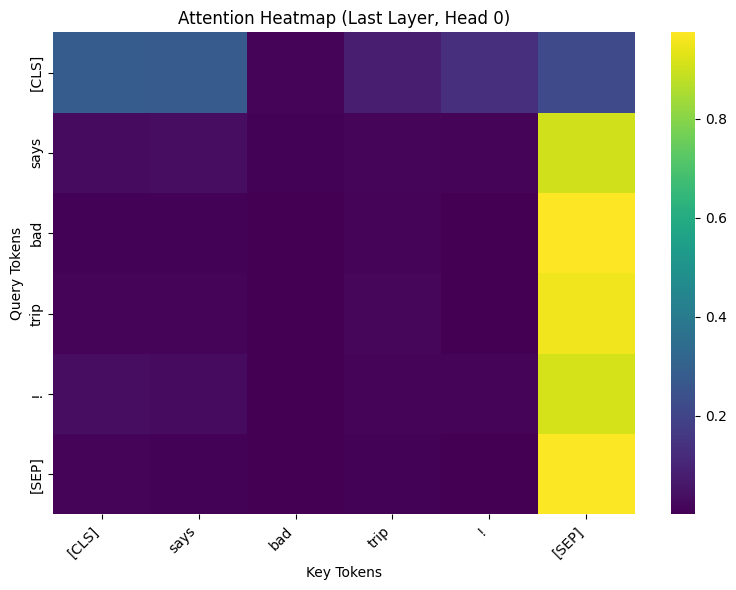

In [8]:
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

attention = attentions[-1][0][0].detach().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("Attention Heatmap (Last Layer, Head 0)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()